# Data Description:
The detailed data dictionary is given below:

- Suburb - Suburb in which the property is located
- Rooms - Number of rooms in the property
- Type - Type of the property like
    h - house,cottage,villa, semi,terrace,
    t - townhouse,
- u - unit, duplex
- SellerG - Name of the real estate agent who sold the property
- Date - Date on which the property was sold
- Distance - Distance of the property from CBD in kilometres. CBD is the central business district of the city.
- Postcode - Postcode of the area
- Bedroom - Number of bedrooms in the property
- Bathroom - Number of bathrooms in the property
- Car - Number of car parking spaces in the property
- Landsize - Size of the land in square metres
- BuildingArea - Size of the building in square metres (Generally, building size is smaller than land size since someone can have personal gardens and other things in the property.)
- YearBuilt - Year in which the building was built
- Regionname - Name of the region in which the property is located like - Eastern Metropolitan, Western Metropolitan, Northern Victoria etc.
- Propertycount - Number of properties that are present in the suburb
- Price - price (in AUD) at which the property was sold

#### Sanity Check

##### Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x : '%.3f'% x)  # float value to 3 decimal places

In [ ]:
filepath ='/content/drive/MyDrive/Edgeverve datasets/Melbourne_Housing-1.csv'

##### Importing Dataset

In [ ]:
data = pd.read_csv(filepath)

##### view the first and last 5 rows of the data

In [ ]:
data.head(10)

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price
0,Airport West,3,t,Nelson,03-09-2016,13.500,3042.000,3.000,2.000,1.000,303.000,225,2016.000,Western Metropolitan,3464,840000
1,Albert Park,2,h,hockingstuart,03-09-2016,3.300,3206.000,2.000,1.000,0.000,120.000,82,1900.000,Southern Metropolitan,3280,1275000
2,Albert Park,2,h,Thomson,03-09-2016,3.300,3206.000,2.000,1.000,0.000,159.000,inf,NaN,Southern Metropolitan,3280,1455000
3,Alphington,4,h,Brace,03-09-2016,6.400,3078.000,3.000,2.000,4.000,853.000,263,1930.000,Northern Metropolitan,2211,2000000
4,Alphington,3,h,Jellis,03-09-2016,6.400,3078.000,3.000,2.000,2.000,208.000,inf,2013.000,Northern Metropolitan,2211,1110000
5,Altona,3,h,Greg,03-09-2016,13.800,3018.000,3.000,2.000,1.000,352.000,242,2015.000,Western Metropolitan,5301,520000
6,Altona North,5,h,FN,03-09-2016,11.100,3025.000,5.000,3.000,6.000,592.000,251,1965.000,Western Metropolitan,5132,1085000
7,Altona North,3,h,Jas,03-09-2016,11.100,3025.000,3.000,1.000,2.000,533.000,117,1970.000,Western Metropolitan,5132,781000
8,Altona North,4,h,hockingstuart,03-09-2016,11.100,3025.000,NaN,NaN,NaN,NaN,missing,NaN,Western Metropolitan,5132,857500
9,Armadale,2,u,Jellis,03-09-2016,6.300,3143.000,2.000,1.000,1.000,50.000,76,1964.000,Southern Metropolitan,4836,599000


In [ ]:
data.tail()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price
27109,Noble Park,3,h,C21,30-09-2017,22.700,3174.000,3.000,1.000,6.000,569.000,130,1959.000,South-Eastern Metropolitan,11806,627500
27110,Reservoir,3,u,RW,30-09-2017,12.000,3073.000,3.000,1.000,1.000,NaN,105,1990.000,Northern Metropolitan,21650,475000
27111,Roxburgh Park,4,h,Raine,30-09-2017,20.600,3064.000,4.000,2.000,2.000,NaN,225,1995.000,Northern Metropolitan,5833,591000
27112,Springvale South,3,h,Harcourts,30-09-2017,22.200,3172.000,3.000,2.000,1.000,544.000,NaN,NaN,South-Eastern Metropolitan,4054,780500
27113,Westmeadows,4,h,Barry,30-09-2017,16.500,3049.000,4.000,2.000,6.000,813.000,140,1960.000,Northern Metropolitan,2474,791000


##### Understand the shape of the data

In [ ]:
print(f'No of rows  {data.shape[0]}  No of columns  {data.shape[1]}')

No of rows  27114  No of columns  16


##### Check the datatype of columns for the dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27114 entries, 0 to 27113
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         27114 non-null  object 
 1   Rooms          27114 non-null  int64  
 2   Type           27114 non-null  object 
 3   SellerG        27114 non-null  object 
 4   Date           27114 non-null  object 
 5   Distance       27113 non-null  float64
 6   Postcode       27113 non-null  float64
 7   Bedroom        20678 non-null  float64
 8   Bathroom       20672 non-null  float64
 9   Car            20297 non-null  float64
 10  Landsize       17873 non-null  float64
 11  BuildingArea   10543 non-null  object 
 12  YearBuilt      11985 non-null  float64
 13  Regionname     27114 non-null  object 
 14  Propertycount  27114 non-null  int64  
 15  Price          27114 non-null  int64  
dtypes: float64(7), int64(3), object(6)
memory usage: 3.3+ MB


- There are 10 numerical columns in the data and 6 object type columns.
- Date column being read as object type column but it should be in date- time format
- Building area is read as object column but it should be numeric

In [ ]:
# changing the datatype of date column
data['Date'] = pd.to_datetime(data['Date'] , format= "%d-%m-%Y")

In [ ]:
data['BuildingArea'].unique()

array(['225', '82', 'inf', '263', '242', '251', '117', 'missing', '76',
       '399', '118', '103', '180', '123', '218', '129', '167', '154',
       '275', '121', nan, '125', '255', '75', '156', '240', '268', '108',
       '69', '140', '214', '253', '189', '215', '96', '104', '100', '313',
       '144', '93', '110', '70', '122', '51', '147', '113', '83', '56',
       '137', '85', '64', '175', '3558', '170', '265', '353', '138', '19',
       '116', '87', '74', '320', '300', '210', '120', '86', '97', '200',
       '106', '14', '161', '128', '185', '146', '133', '115', '143',
       '150', '195', '236', '276', '188', '179', '249', '141', '34', '73',
       '107', '84', '81', '207', '50', '264', '312', '235', '221', '183',
       '132', '160', '186', '78', '105', '145', '62', '220', '315', '181',
       '61', '112', '420', '226', '266', '410', '449', '356', '477',
       '250', '95', '190', '284', '247', '213', '209', '119', '111',
       '130', '348', '166', '44', '176', '98', '159', '79'

In [ ]:
# No of unique building area values
data['BuildingArea'].nunique()

655

In [ ]:
# checking the count of different data types in building area columns
data['BuildingArea'] .apply(type).value_counts()

,count
BuildingArea,
<class 'float'>,16571
<class 'str'>,10543


- we can see there are mixed data types value in building area columns like missing , inf , which should be read as missing value NAN .Let replace such data points with null values

In [ ]:
# replace values with nan
data['BuildingArea'] = data['BuildingArea'].replace(['missing','inf'],np.nan)
# change data type to float
data['BuildingArea'] = data['BuildingArea'].astype(float)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27114 entries, 0 to 27113
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         27114 non-null  object        
 1   Rooms          27114 non-null  int64         
 2   Type           27114 non-null  object        
 3   SellerG        27114 non-null  object        
 4   Date           27114 non-null  datetime64[ns]
 5   Distance       27113 non-null  float64       
 6   Postcode       27113 non-null  float64       
 7   Bedroom        20678 non-null  float64       
 8   Bathroom       20672 non-null  float64       
 9   Car            20297 non-null  float64       
 10  Landsize       17873 non-null  float64       
 11  BuildingArea   10529 non-null  float64       
 12  YearBuilt      11985 non-null  float64       
 13  Regionname     27114 non-null  object        
 14  Propertycount  27114 non-null  int64         
 15  Price          2711

##### Checking for missing values in the data

In [ ]:
data.isnull().sum()

,0
Suburb,0
Rooms,0
Type,0
SellerG,0
Date,0
Distance,1
Postcode,1
Bedroom,6436
Bathroom,6442
Car,6817


##### checking for duplicate entries in the data

In [ ]:
data.duplicated().sum()

np.int64(11)

In [ ]:
# remove duplicate enteries from the data
data.drop_duplicates(inplace=True)

In [ ]:
# reset the index of data frame since rows have been removed
data.reset_index(drop=True,inplace=True)

##### Check statistical Summary Of The Data

In [ ]:
data.describe()

,Rooms,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Propertycount,Price
count,27103.000,27103,27102.000,27102.000,20678.000,20672.000,20297.000,17873.000,10529.000,11985.000,27103.000,27103.000
mean,2.992,2017-05-23 12:25:09.441759488,11.280,3113.787,3.046,1.592,1.716,560.537,154.512,1966.618,7564.741,1050664.131
min,1.000,2016-01-28 00:00:00,0.000,3000.000,0.000,0.000,0.000,50.000,11.000,1850.000,83.000,85000.000
25%,2.000,2016-11-19 00:00:00,6.400,3046.000,2.000,1.000,1.000,220.000,101.000,1950.000,4294.000,635000.000
50%,3.000,2017-07-08 00:00:00,10.500,3088.000,3.000,1.000,2.000,513.000,133.000,1970.000,6567.000,871000.000
75%,4.000,2017-10-28 00:00:00,14.000,3153.000,4.000,2.000,2.000,664.000,183.000,2000.000,10412.000,1300000.000
max,16.000,2018-03-17 00:00:00,48.100,3978.000,20.000,9.000,18.000,76000.000,6791.000,2019.000,21650.000,11200000.000
std,0.955,NaN,6.784,111.129,0.955,0.701,0.994,1411.309,130.584,36.042,4494.028,641660.161


In [ ]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Rooms,27103.000,2.992,1.000,2.000,3.000,4.000,16.000,0.955
Date,27103,2017-05-23 12:25:09.441759488,2016-01-28 00:00:00,2016-11-19 00:00:00,2017-07-08 00:00:00,2017-10-28 00:00:00,2018-03-17 00:00:00,NaN
Distance,27102.000,11.280,0.000,6.400,10.500,14.000,48.100,6.784
Postcode,27102.000,3113.787,3000.000,3046.000,3088.000,3153.000,3978.000,111.129
Bedroom,20678.000,3.046,0.000,2.000,3.000,4.000,20.000,0.955
Bathroom,20672.000,1.592,0.000,1.000,1.000,2.000,9.000,0.701
Car,20297.000,1.716,0.000,1.000,2.000,2.000,18.000,0.994
Landsize,17873.000,560.537,50.000,220.000,513.000,664.000,76000.000,1411.309
BuildingArea,10529.000,154.512,11.000,101.000,133.000,183.000,6791.000,130.584
YearBuilt,11985.000,1966.618,1850.000,1950.000,1970.000,2000.000,2019.000,36.042


In [ ]:
data['Postcode'].nunique()

209

In [ ]:
cat_cols=['Suburb','Type','SellerG','Regionname']
# check count of  unique cat levels in each columns
for column in cat_cols:
  print(data[column].value_counts())
  print('----'*80)

Suburb
Reservoir         724
Bentleigh East    493
Richmond          437
Preston           410
Brunswick         383
                 ... 
Darley              1
Eynesbury           1
croydon             1
Monbulk             1
viewbank            1
Name: count, Length: 345, dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Type
h    18394
u     5882
t     2827
Name: count, dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Seller

In [ ]:
### Univariate Analysis

<Axes: xlabel='Distance', ylabel='Count'>

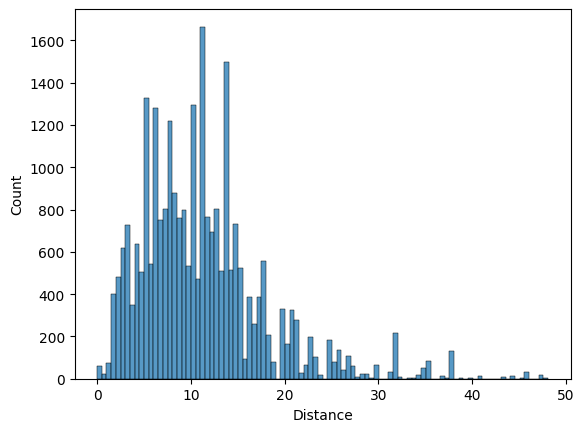

In [ ]:
sns.histplot(data=data,x='Distance')

<Axes: xlabel='Distance'>

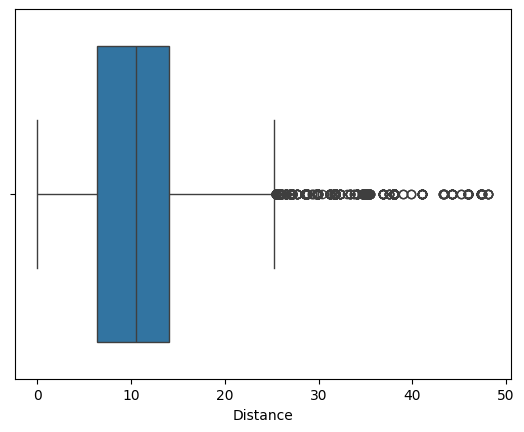

In [ ]:
sns.boxplot(data=data,x='Distance')

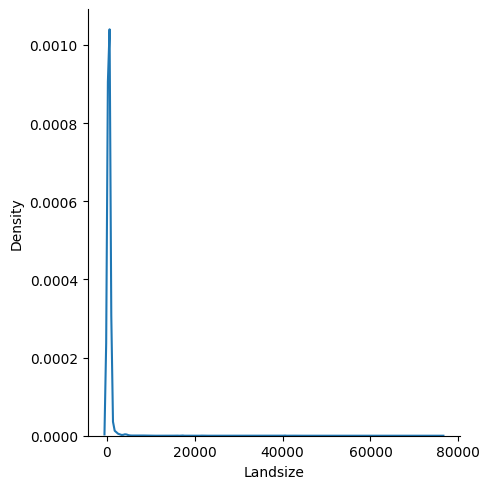

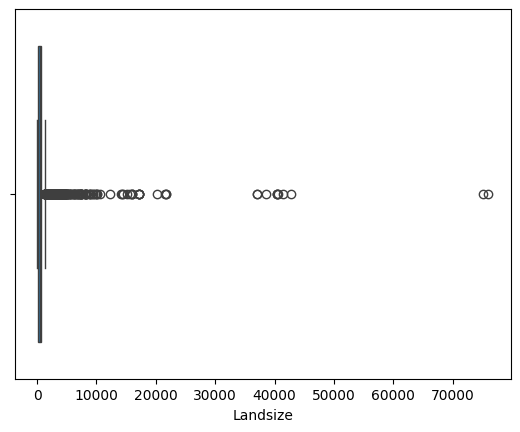

In [ ]:
sns.displot(data=data,x='Landsize',kind='kde')
plt.show()
sns.boxplot(data=data,x='Landsize')
plt.show()

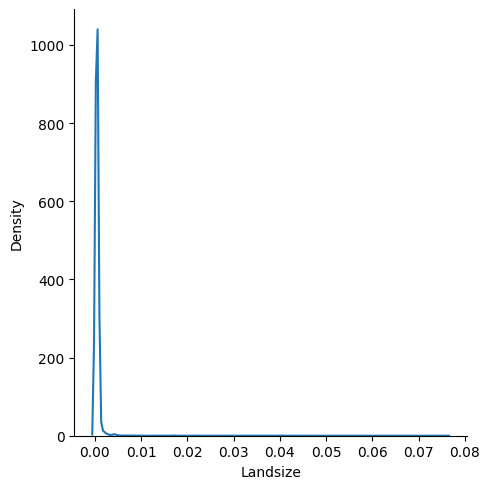

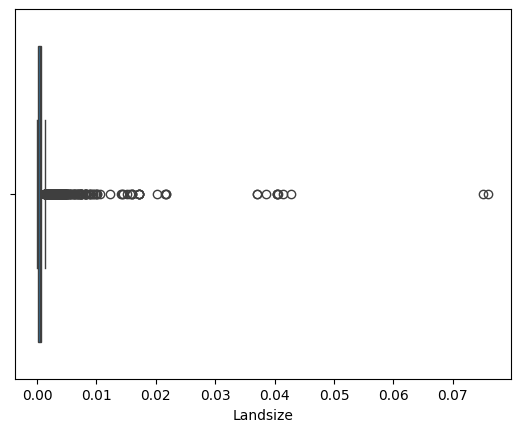

In [ ]:
sns.displot(data=data,x=data['Landsize']/1000000,kind='kde')
plt.show()
sns.boxplot(data=data,x=data['Landsize']/1000000)
plt.show()

In [ ]:
data.loc[data['Landsize']>60000]

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price
23897,Silvan,3,h,Harcourts,2017-05-27,34.600,3795.000,3.000,2.000,2.000,76000.000,NaN,NaN,Eastern Victoria,457,1085000
25079,Balwyn North,3,h,Kay,2016-08-28,9.200,3104.000,3.000,1.000,2.000,75100.000,NaN,NaN,Southern Metropolitan,7809,2000000


#### observation on building area

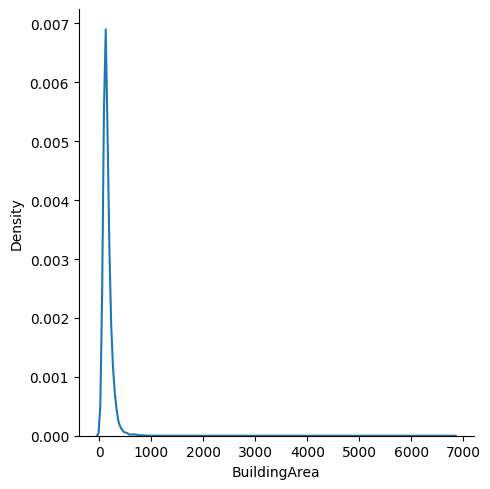

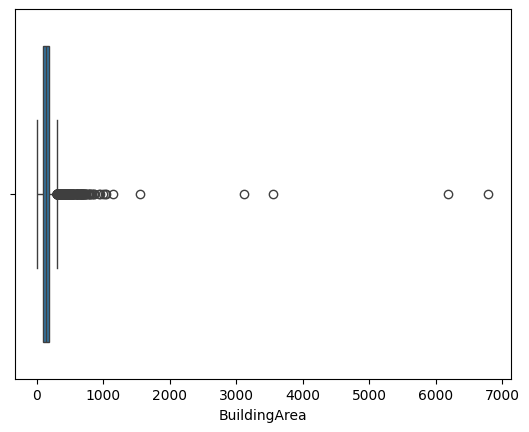

In [ ]:
sns.displot(data=data,x='BuildingArea',kind='kde')
plt.show()
sns.boxplot(data=data,x='BuildingArea')
plt.show()

#### Observation on price

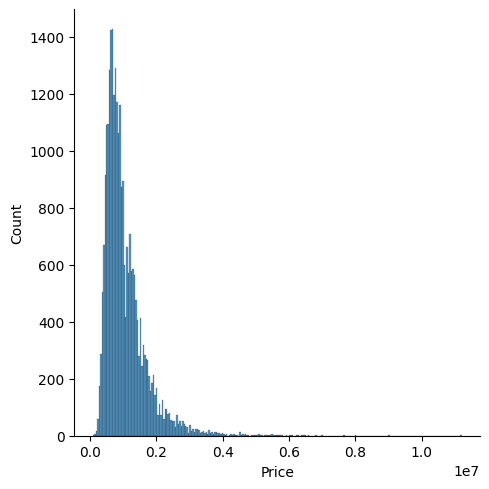

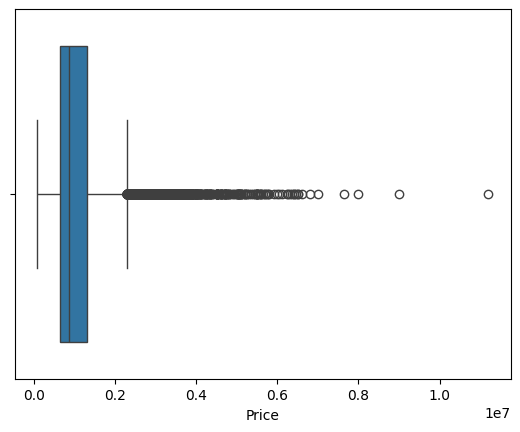

In [ ]:
sns.displot(data=data,x='Price')
plt.show()
sns.boxplot(data=data,x='Price')
plt.show()

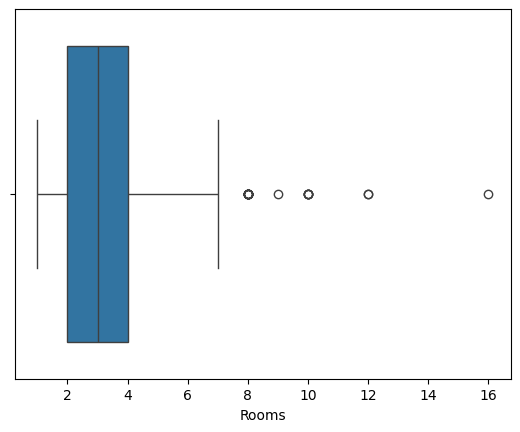

In [ ]:
# observation on rooms
sns.boxplot(data=data,x='Rooms')
plt.show()

In [ ]:
data.loc[data['Rooms']>7]

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price
896,Templestowe Lower,8,h,Barry,2016-06-04,13.800,3107.000,6.000,4.000,3.000,668.000,NaN,NaN,Eastern Metropolitan,5420,1150000
2012,Ashburton,8,h,hockingstuart,2016-09-10,11.000,3147.000,9.000,7.000,4.000,1472.000,618.000,2009.000,Southern Metropolitan,3052,2950000
2186,Oakleigh South,9,h,Ray,2016-09-10,14.700,3167.000,NaN,NaN,NaN,NaN,NaN,NaN,South-Eastern Metropolitan,3692,1380000
2556,Parkville,8,u,Kelly,2016-12-10,2.600,3052.000,NaN,NaN,NaN,NaN,NaN,NaN,Northern Metropolitan,2309,3210000
4597,Coburg,8,u,Peter,2017-03-04,7.800,3058.000,4.000,2.000,4.000,983.000,NaN,NaN,Northern Metropolitan,11204,2250000
5480,Newport,8,h,Greg,2017-10-07,6.200,3015.000,8.000,1.000,2.000,NaN,NaN,NaN,Western Metropolitan,5498,1405000
6037,Camberwell,8,h,Ross,2017-07-08,7.700,3124.000,8.000,8.000,4.000,650.000,NaN,NaN,Southern Metropolitan,8920,2200000
7986,Melton,12,h,PRDNationwide,2017-11-11,31.700,3337.000,12.000,5.000,3.000,960.000,223.000,1970.000,Western Victoria,3600,710000
10455,Brighton East,8,h,Buxton,2017-05-13,10.700,3187.000,8.000,3.000,3.000,614.000,NaN,NaN,Southern Metropolitan,6938,1880000
11248,Burwood,8,h,RW,2017-10-14,10.400,3125.000,8.000,3.000,NaN,NaN,114.000,1950.000,Southern Metropolitan,5678,1666766


In [ ]:
data.loc[data['Rooms']>7].shape

(23, 16)

In [ ]:
# finding the type of properties that have room more the 7
data.loc[data['Rooms']>7,'Type'].value_counts()

,count
Type,
h,21
u,2


- there is no townhouse
- most of the properties are house/ villas
- this indicates h type properties are more likely choice for customers who are looking for bigger properties

### Observation On Region Name

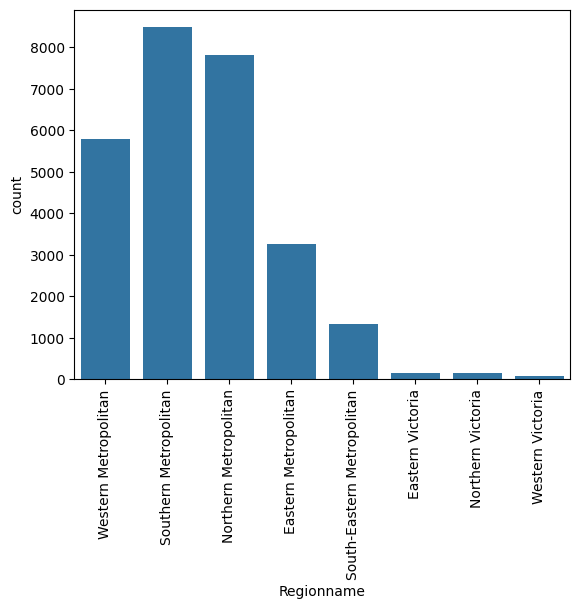

In [ ]:
sns.countplot(data=data,x='Regionname')
plt.xticks(rotation=90)
plt.show()

### Bivariant Analysis

In [ ]:
data.corr(numeric_only=True)


,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Propertycount,Price
Rooms,1.000,0.284,0.081,0.959,0.609,0.394,0.071,0.418,-0.004,-0.080,0.465
Distance,0.284,1.000,0.490,0.283,0.140,0.245,0.118,0.102,0.321,-0.021,-0.211
Postcode,0.081,0.490,1.000,0.087,0.124,0.063,0.076,0.060,0.100,0.024,0.045
Bedroom,0.959,0.283,0.087,1.000,0.606,0.396,0.071,0.413,0.006,-0.060,0.430
Bathroom,0.609,0.140,0.124,0.606,1.000,0.306,0.055,0.389,0.187,-0.040,0.431
Car,0.394,0.245,0.063,0.396,0.306,1.000,0.092,0.218,0.133,-0.014,0.201
Landsize,0.071,0.118,0.076,0.071,0.055,0.092,1.000,0.058,0.045,-0.020,0.043
BuildingArea,0.418,0.102,0.060,0.413,0.389,0.218,0.058,1.000,0.079,-0.042,0.336
YearBuilt,-0.004,0.321,0.100,0.006,0.187,0.133,0.045,0.079,1.000,0.027,-0.340
Propertycount,-0.080,-0.021,0.024,-0.060,-0.040,-0.014,-0.020,-0.042,0.027,1.000,-0.059


In [ ]:
# df [column]=[value] creating new column name as total space  is sum of bedroom + bathroom + car + room
data['Total Space'] = data['Bathroom']+data['Bedroom']+data['Rooms'] + data['Car']
data.head()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price,Total Space
0,Airport West,3,t,Nelson,2016-09-03,13.500,3042.000,3.000,2.000,1.000,303.000,225.000,2016.000,Western Metropolitan,3464,840000,9.000
1,Albert Park,2,h,hockingstuart,2016-09-03,3.300,3206.000,2.000,1.000,0.000,120.000,82.000,1900.000,Southern Metropolitan,3280,1275000,5.000
2,Albert Park,2,h,Thomson,2016-09-03,3.300,3206.000,2.000,1.000,0.000,159.000,NaN,NaN,Southern Metropolitan,3280,1455000,5.000
3,Alphington,4,h,Brace,2016-09-03,6.400,3078.000,3.000,2.000,4.000,853.000,263.000,1930.000,Northern Metropolitan,2211,2000000,13.000
4,Alphington,3,h,Jellis,2016-09-03,6.400,3078.000,3.000,2.000,2.000,208.000,NaN,2013.000,Northern Metropolitan,2211,1110000,10.000


/tmp/ipykernel_2402/3544542009.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=data,x='Total Space',y='Price',alpha=0.6,palette='coolwarm')


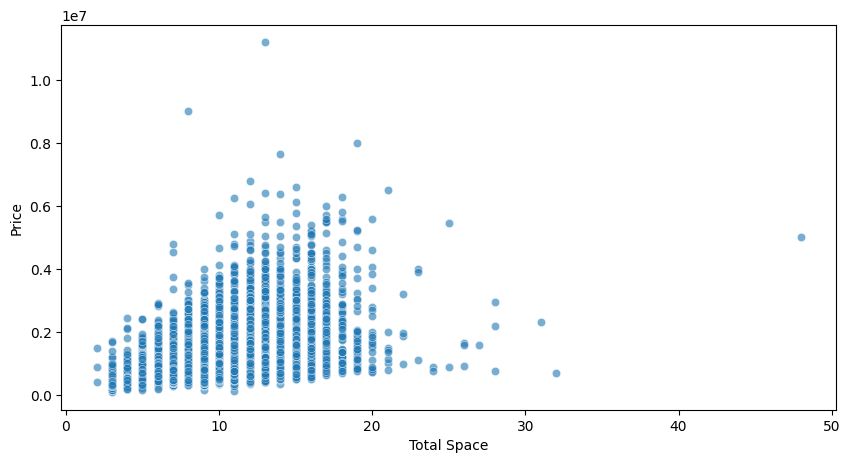

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=data,x='Total Space',y='Price',alpha=0.6,palette='coolwarm')
plt.show()

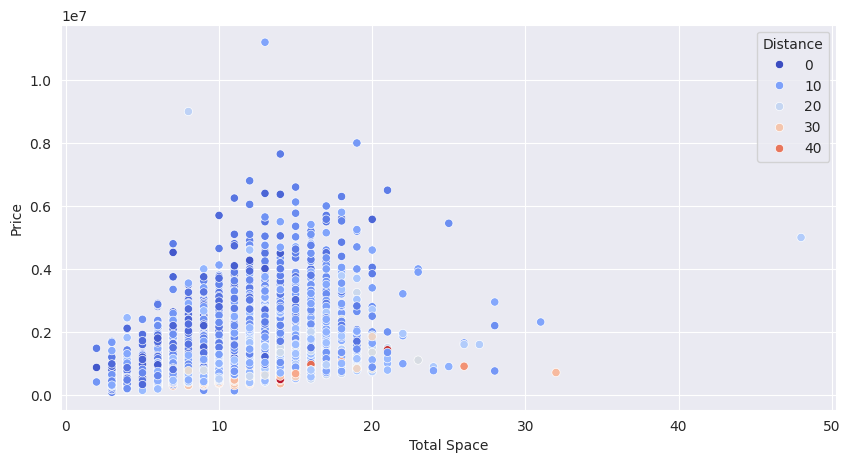

In [ ]:
plt.figure(figsize=(10,5))
sns.set_style('darkgrid')  # white, dark, ticks , darkgrid , whitegrid
sns.scatterplot(data=data,x='Total Space',y='Price',hue='Distance',palette='coolwarm')
plt.show()

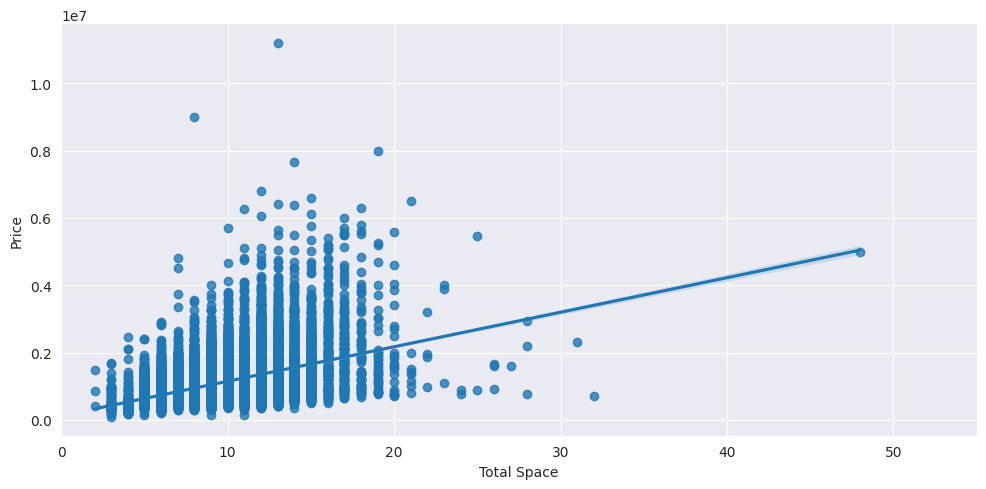

In [ ]:
sns.lmplot(data=data,x='Total Space',y='Price',height=5,aspect=2)
plt.xlim(0,55)
plt.show()

In [ ]:
data[['Total Space','Price']].corr()

,Total Space,Price
Total Space,1.000,0.458
Price,0.458,1.000


In [ ]:
# distance vs price

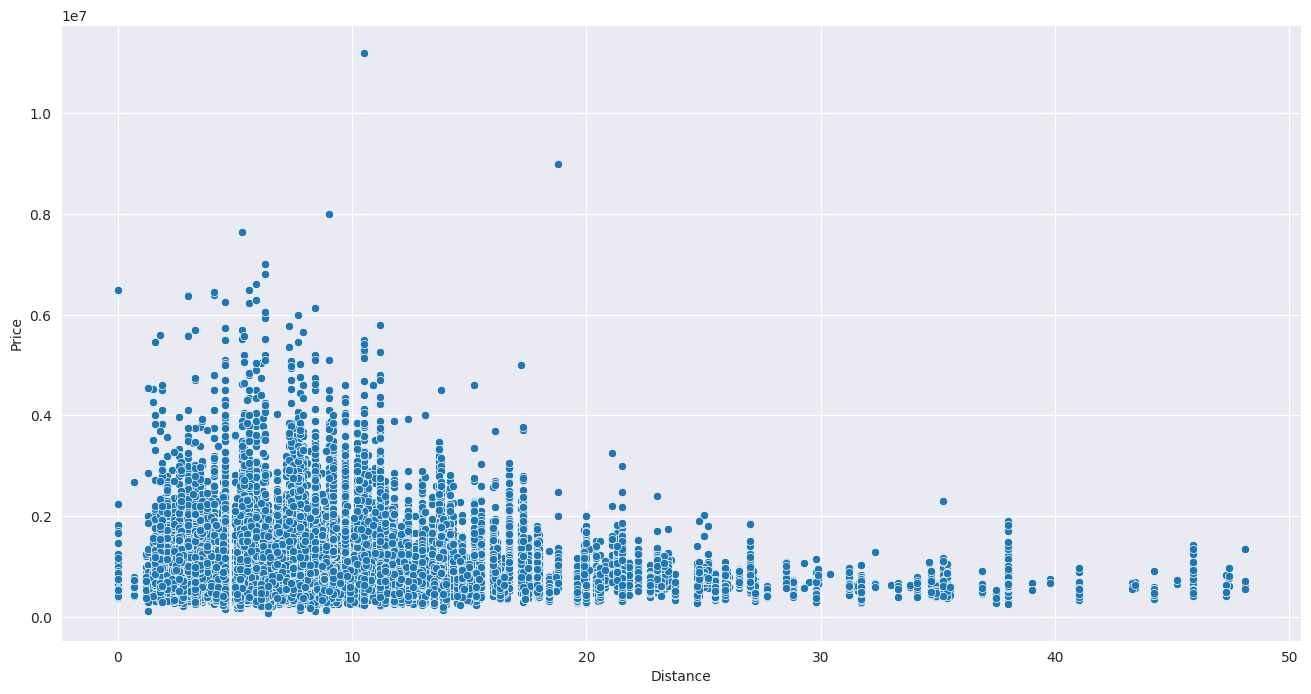

In [ ]:
plt.figure(figsize=(16,8))
sns.scatterplot(data=data,x='Distance',y='Price')
plt.show()

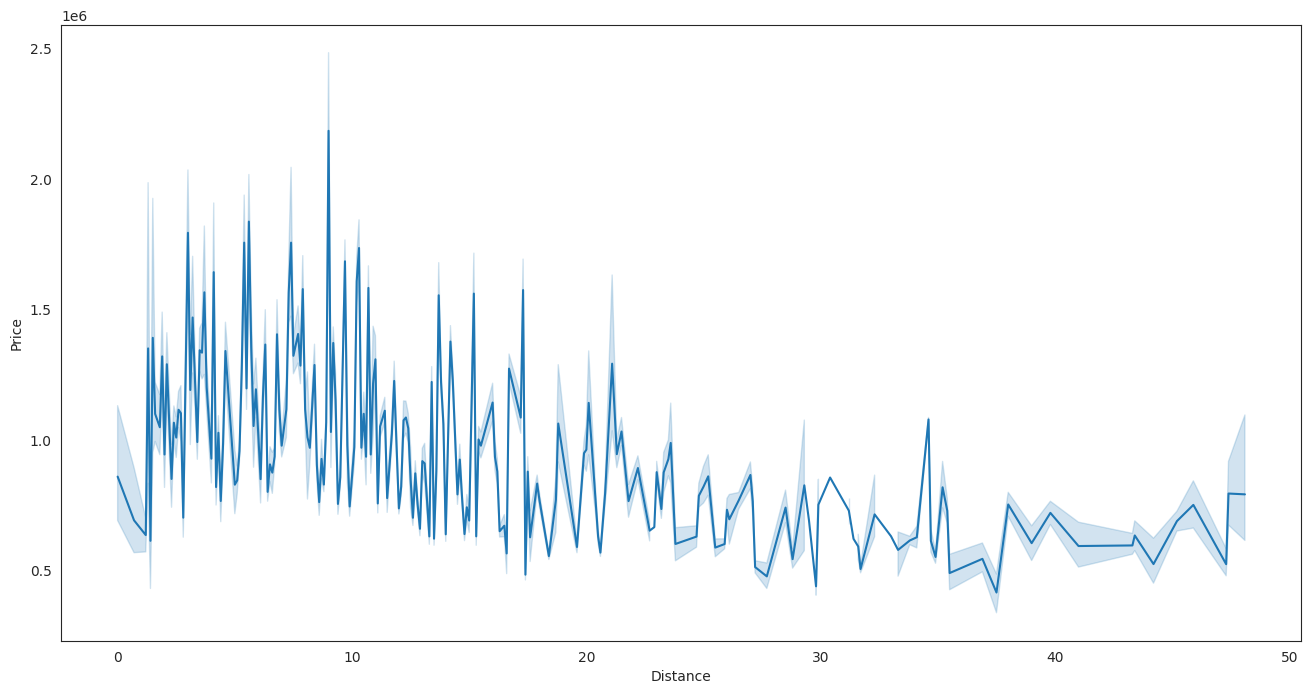

In [ ]:
plt.figure(figsize=(16,8))
sns.set_style('white')
sns.lineplot(data=data,x='Distance',y='Price')
plt.show()

##### creating bins  -- pd.cut(x,bins , labels , right=False)
- 0 - 15Kms  - NearBy
- 15 - 30 kms  -  Moderately close
- 30 -50  - Far away location

In [ ]:
data['Distance_bins'] =  pd.cut(data['Distance'],bins=[0,15,30,50],labels=['NearBy','Moderately close','Far'])
data.head()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price,Total Space,Distance_bins
0,Airport West,3,t,Nelson,2016-09-03,13.500,3042.000,3.000,2.000,1.000,303.000,225.000,2016.000,Western Metropolitan,3464,840000,9.000,NearBy
1,Albert Park,2,h,hockingstuart,2016-09-03,3.300,3206.000,2.000,1.000,0.000,120.000,82.000,1900.000,Southern Metropolitan,3280,1275000,5.000,NearBy
2,Albert Park,2,h,Thomson,2016-09-03,3.300,3206.000,2.000,1.000,0.000,159.000,NaN,NaN,Southern Metropolitan,3280,1455000,5.000,NearBy
3,Alphington,4,h,Brace,2016-09-03,6.400,3078.000,3.000,2.000,4.000,853.000,263.000,1930.000,Northern Metropolitan,2211,2000000,13.000,NearBy
4,Alphington,3,h,Jellis,2016-09-03,6.400,3078.000,3.000,2.000,2.000,208.000,NaN,2013.000,Northern Metropolitan,2211,1110000,10.000,NearBy


In [ ]:
data.tail()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price,Total Space,Distance_bins
27098,Noble Park,3,h,C21,2017-09-30,22.700,3174.000,3.000,1.000,6.000,569.000,130.000,1959.000,South-Eastern Metropolitan,11806,627500,13.000,Moderately close
27099,Reservoir,3,u,RW,2017-09-30,12.000,3073.000,3.000,1.000,1.000,NaN,105.000,1990.000,Northern Metropolitan,21650,475000,8.000,NearBy
27100,Roxburgh Park,4,h,Raine,2017-09-30,20.600,3064.000,4.000,2.000,2.000,NaN,225.000,1995.000,Northern Metropolitan,5833,591000,12.000,Moderately close
27101,Springvale South,3,h,Harcourts,2017-09-30,22.200,3172.000,3.000,2.000,1.000,544.000,NaN,NaN,South-Eastern Metropolitan,4054,780500,9.000,Moderately close
27102,Westmeadows,4,h,Barry,2017-09-30,16.500,3049.000,4.000,2.000,6.000,813.000,140.000,1960.000,Northern Metropolitan,2474,791000,16.000,Moderately close


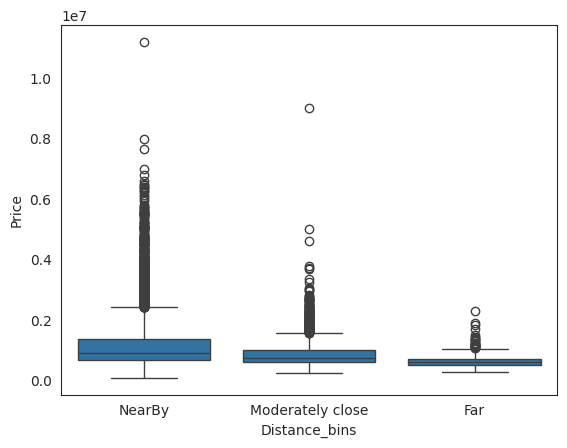

In [ ]:
# check price with distance bins
sns.boxplot(data=data,x='Distance_bins',y='Price')
plt.show()

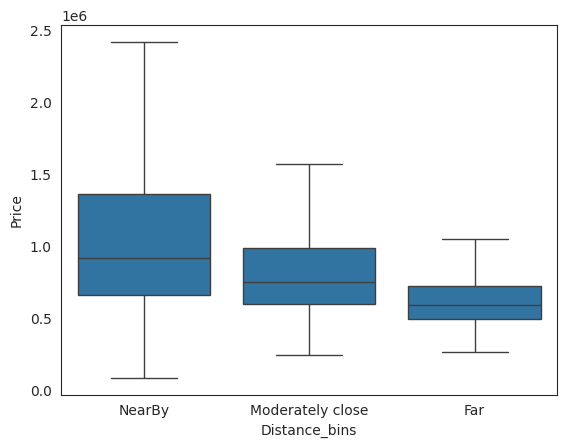

In [ ]:
sns.boxplot(data=data,x='Distance_bins',y='Price',showfliers=False)
plt.show()

In [ ]:
year_at_sale =data['Date'].dt.year
year_at_sale

,Date
0,2016
1,2016
2,2016
3,2016
4,2016
...,...
27098,2017
27099,2017
27100,2017
27101,2017


In [ ]:
data['AgeOfProp']=year_at_sale - data['YearBuilt']
data.head()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price,Total Space,Distance_bins,AgeOfProp
0,Airport West,3,t,Nelson,2016-09-03,13.500,3042.000,3.000,2.000,1.000,303.000,225.000,2016.000,Western Metropolitan,3464,840000,9.000,NearBy,0.000
1,Albert Park,2,h,hockingstuart,2016-09-03,3.300,3206.000,2.000,1.000,0.000,120.000,82.000,1900.000,Southern Metropolitan,3280,1275000,5.000,NearBy,116.000
2,Albert Park,2,h,Thomson,2016-09-03,3.300,3206.000,2.000,1.000,0.000,159.000,NaN,NaN,Southern Metropolitan,3280,1455000,5.000,NearBy,NaN
3,Alphington,4,h,Brace,2016-09-03,6.400,3078.000,3.000,2.000,4.000,853.000,263.000,1930.000,Northern Metropolitan,2211,2000000,13.000,NearBy,86.000
4,Alphington,3,h,Jellis,2016-09-03,6.400,3078.000,3.000,2.000,2.000,208.000,NaN,2013.000,Northern Metropolitan,2211,1110000,10.000,NearBy,3.000


<Axes: xlabel='AgeOfProp', ylabel='Price'>

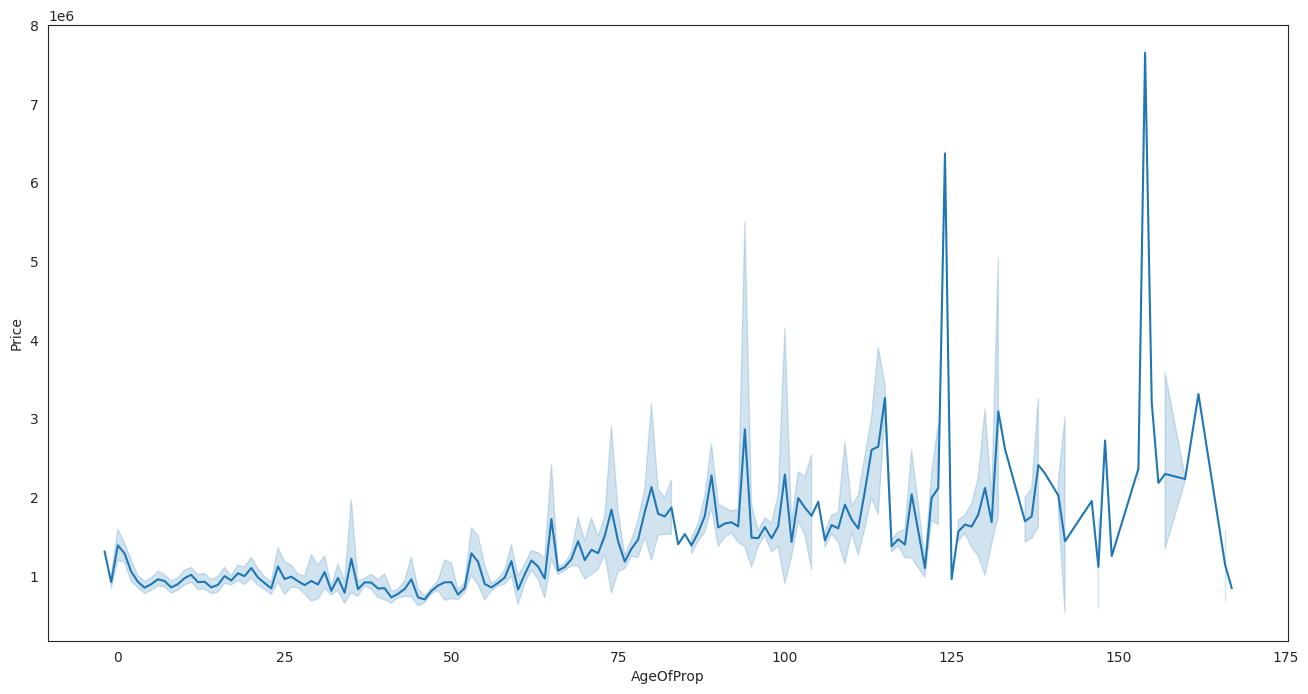

In [ ]:
plt.figure(figsize=(16,8))
sns.lineplot(data=data,x='AgeOfProp',y='Price')

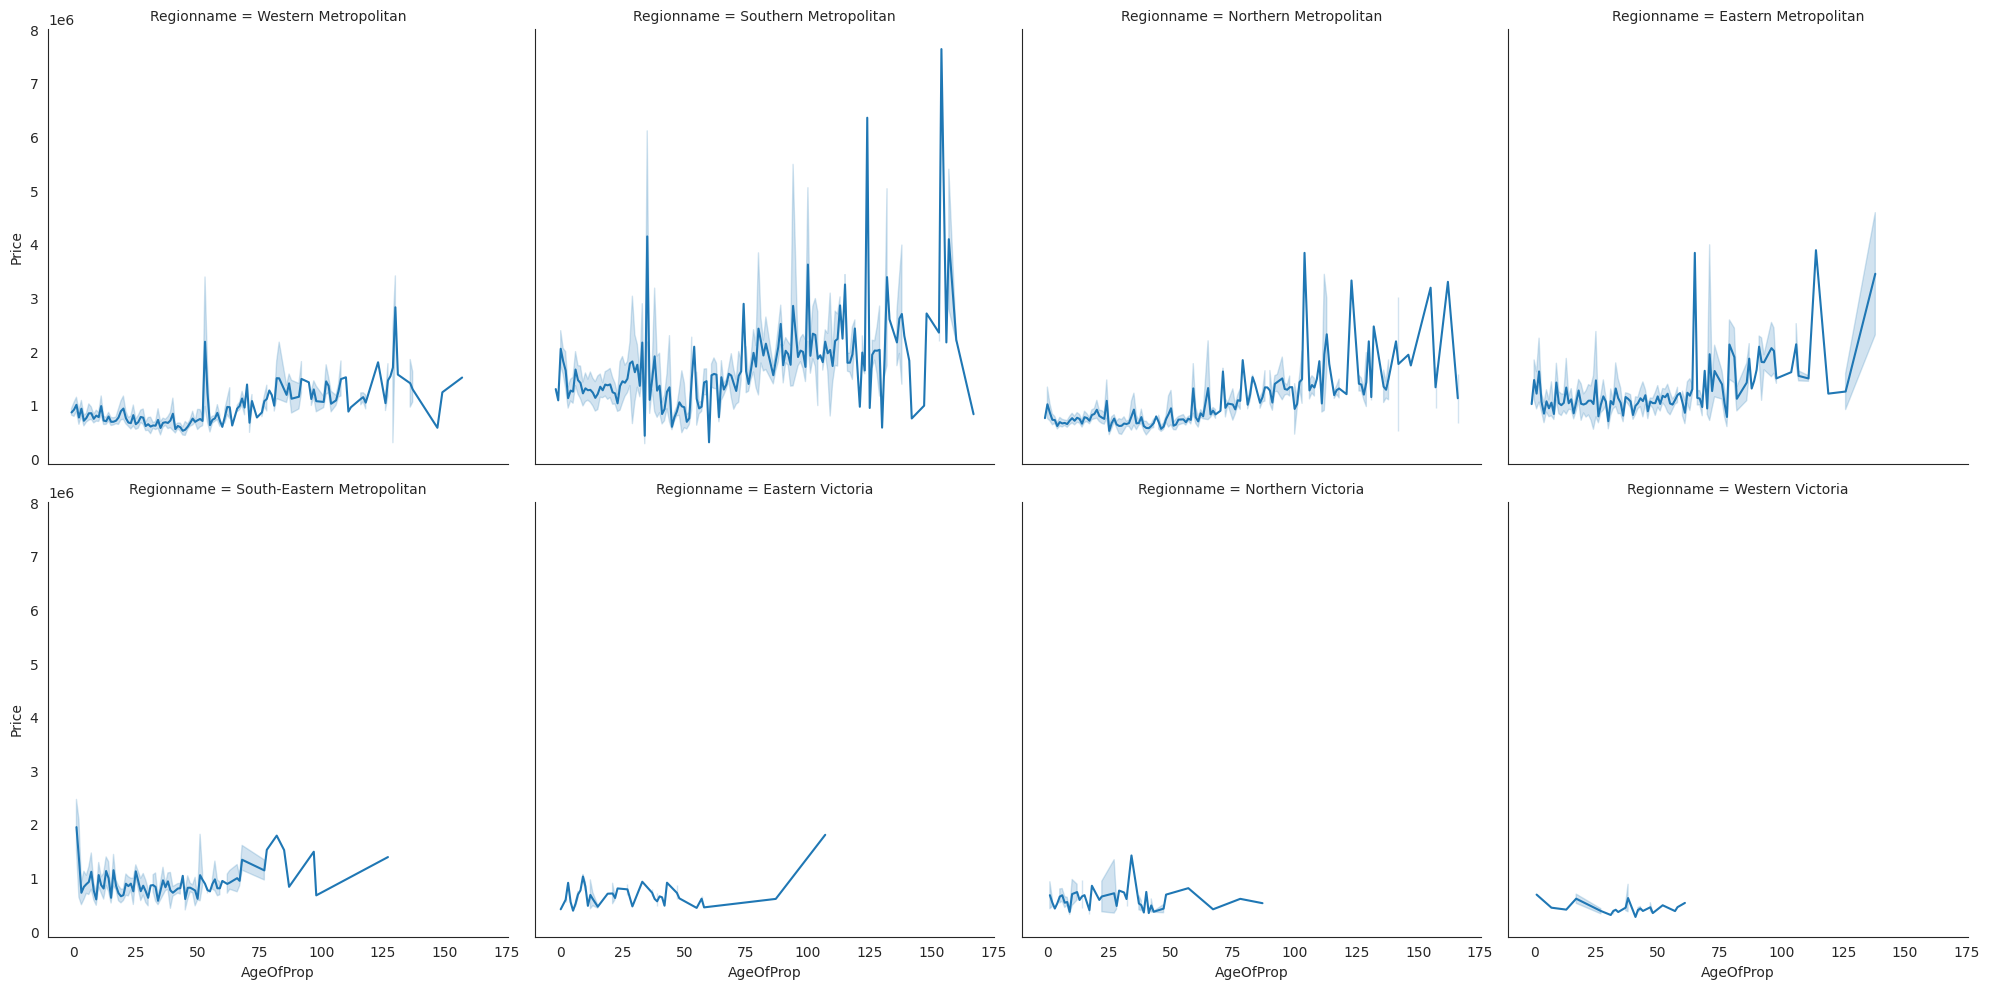

In [ ]:
# relplot() is used to visualize any statistical relationship between quantitative variables.
# relplot(kind = (scatter,line),ci= specifies confidence interval , col_wrap)
sns.relplot(data=data,x='AgeOfProp',y='Price',col='Regionname',kind='line',col_wrap=4)
plt.show()

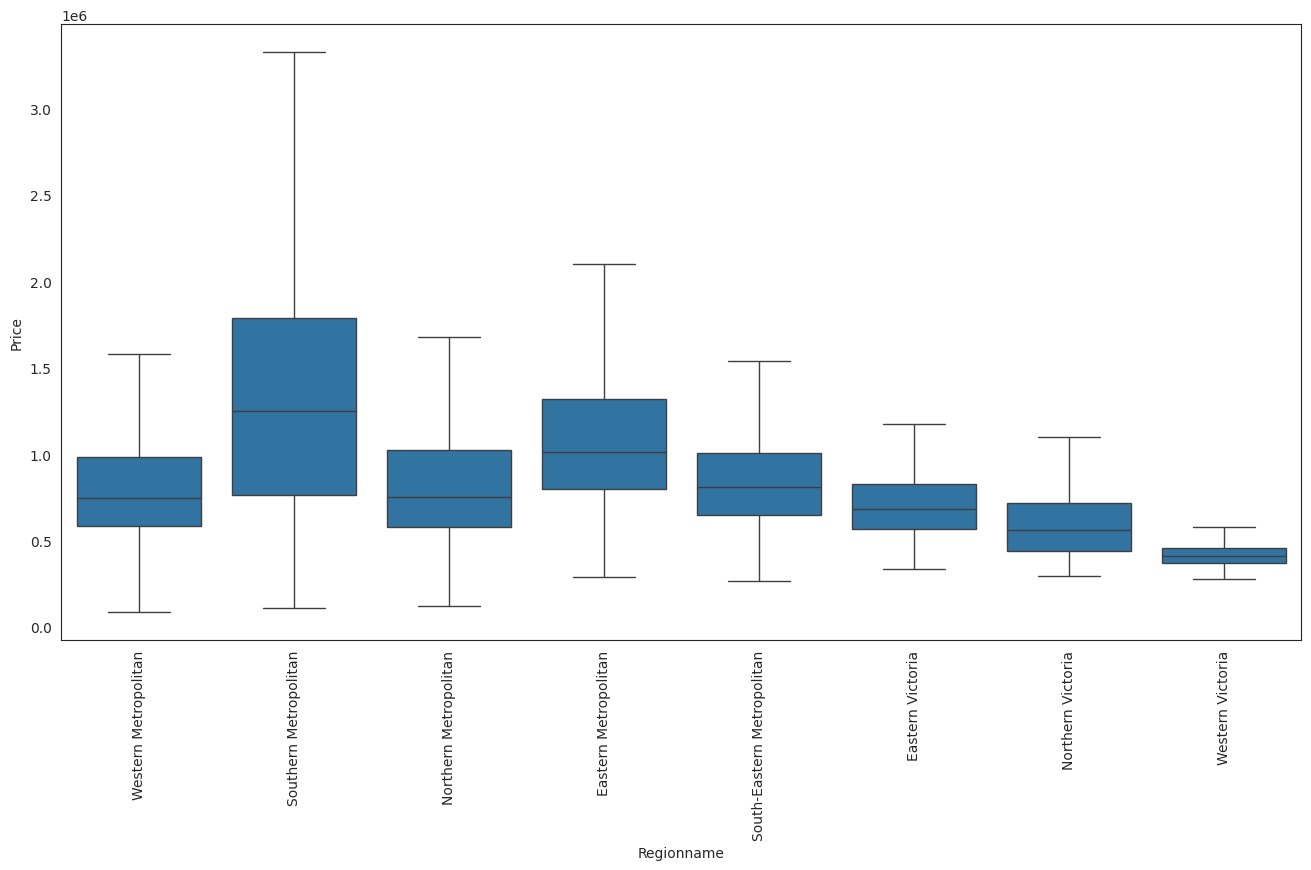

In [ ]:
# region vs price
plt.figure(figsize=(16,8))
sns.boxplot(data=data,x='Regionname',y='Price',showfliers=False)
plt.xticks(rotation=90)
plt.show()



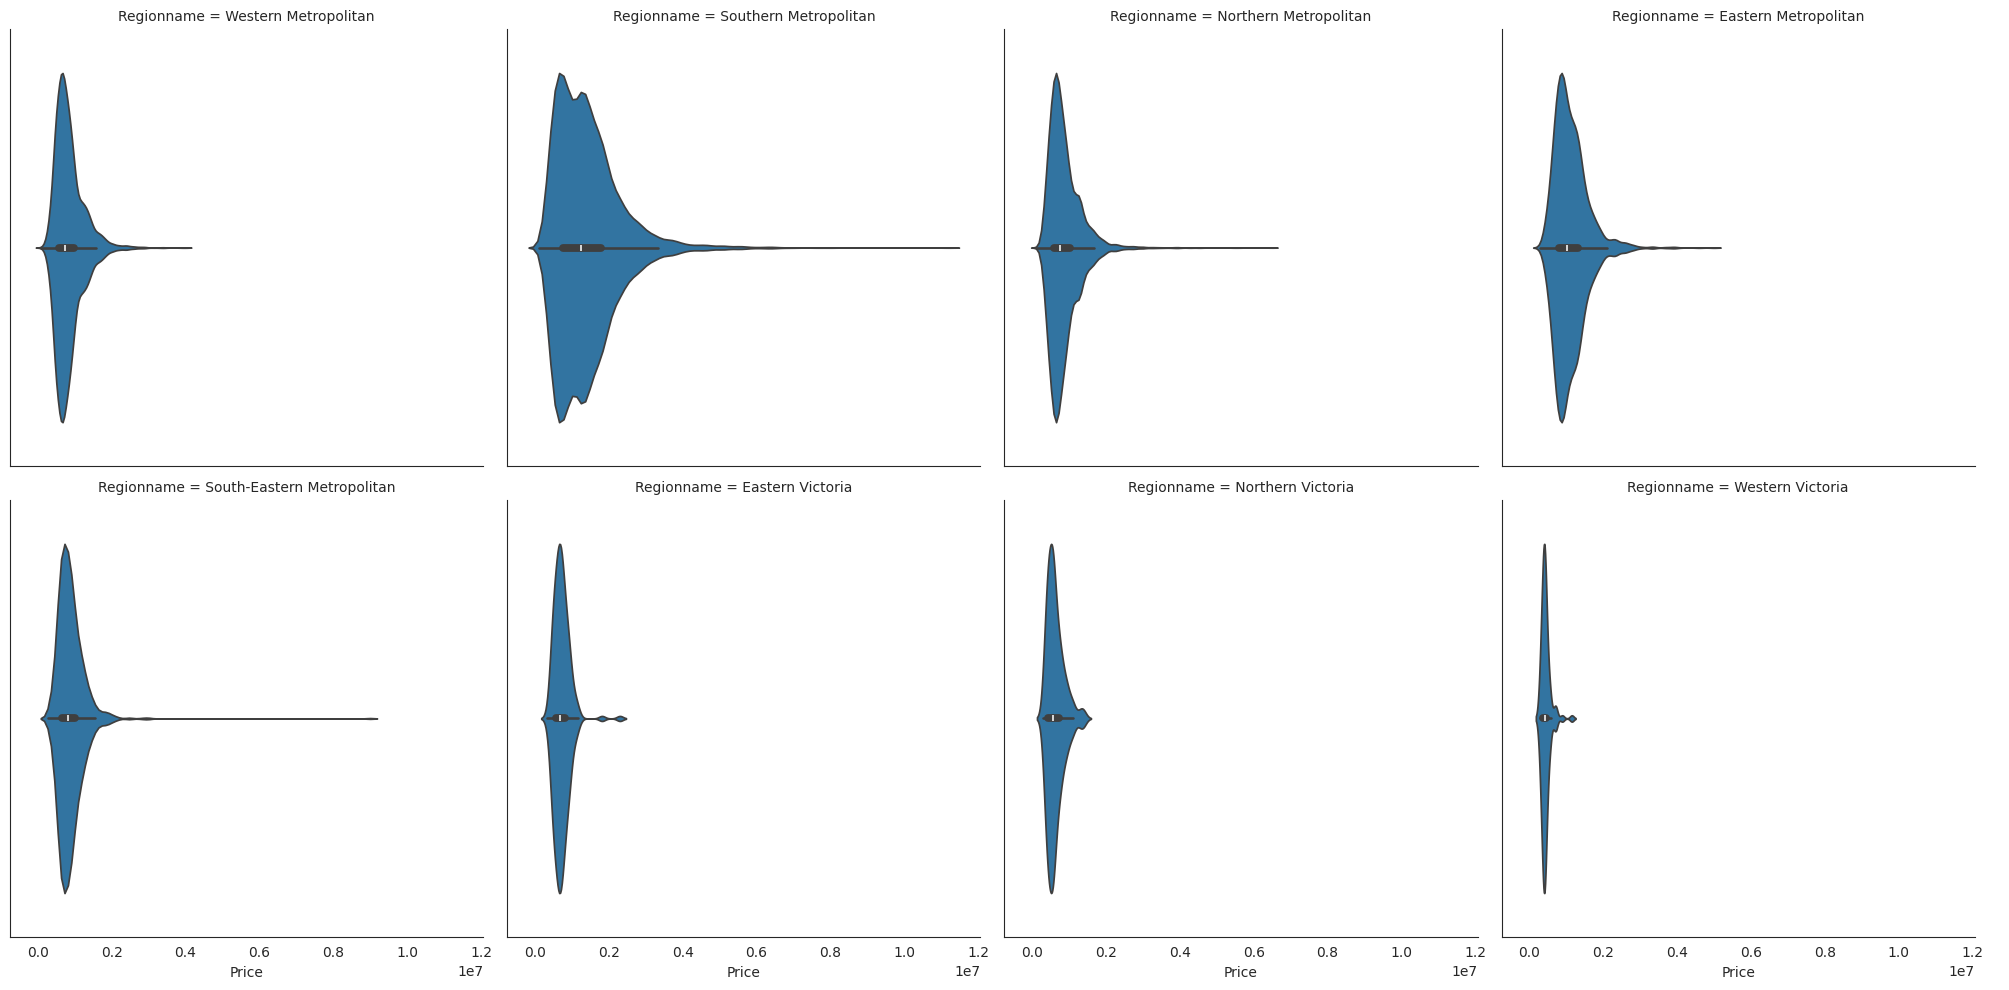

In [ ]:
# dispersion of price in every region
sns.catplot(x='Price',
            col='Regionname',
            data=data,
            col_wrap=4,
            kind='violin')

#### Treating Missing Value   - impute them with central tendencies - mean , median, mode .
- knn , MICE , SMOTE , deep learning

##### Limitation of imputing missing value with central tenddencies

- original distribution get distorted
- after imputation the central value of the variance and std of feature can get
impacted.
- the impact of distortion is higher with higher % of missing value.

In [ ]:
data.isna().sum()

,0
Suburb,0
Rooms,0
Type,0
SellerG,0
Date,0
Distance,1
Postcode,1
Bedroom,6425
Bathroom,6431
Car,6806


In [ ]:
pd.DataFrame(
    {'Count':data.isnull().sum()[data.isnull().sum()>0],
              "Percentage" : (data.isnull().sum()[data.isnull().sum()>0]/data.shape[0])*100
     })


,Count,Percentage
Distance,1,0.004
Postcode,1,0.004
Bedroom,6425,23.706
Bathroom,6431,23.728
Car,6806,25.112
Landsize,9230,34.055
BuildingArea,16574,61.152
YearBuilt,15118,55.780
Total Space,6806,25.112
Distance_bins,59,0.218


##### Missing value imputation for distance

In [ ]:
data.loc[data['Distance'].isnull()==True]

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price,Total Space,Distance_bins,AgeOfProp
9590,Fawkner Lot,3,h,Brad,2018-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Northern Metropolitan,962,616000,NaN,NaN,NaN


In [ ]:
data.loc[data['Suburb']=='Fawkner Lot']

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price,Total Space,Distance_bins,AgeOfProp
9590,Fawkner Lot,3,h,Brad,2018-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Northern Metropolitan,962,616000,NaN,NaN,NaN


In [ ]:
data=data.drop(9590).reset_index(drop=True)  # adding the index value of the row in data.drop()

In [ ]:
pd.DataFrame(
    {'Count':data.isnull().sum()[data.isnull().sum()>0],
              "Percentage" : (data.isnull().sum()[data.isnull().sum()>0]/data.shape[0])*100
     })

,Count,Percentage
Bedroom,6424,23.703
Bathroom,6430,23.725
Car,6805,25.109
Landsize,9229,34.053
BuildingArea,16573,61.150
YearBuilt,15117,55.778
Total Space,6805,25.109
Distance_bins,58,0.214
AgeOfProp,15117,55.778


In [ ]:
# extract all the information of other variable where bedroom is null
data.loc[data['Bedroom'].isnull()==True]

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price,Total Space,Distance_bins,AgeOfProp
8,Altona North,4,h,hockingstuart,2016-09-03,11.100,3025.000,NaN,NaN,NaN,NaN,NaN,NaN,Western Metropolitan,5132,857500,NaN,NearBy,NaN
12,Ashburton,2,h,Marshall,2016-09-03,11.000,3147.000,NaN,NaN,NaN,NaN,NaN,NaN,Southern Metropolitan,3052,1820000,NaN,NearBy,NaN
14,Avondale Heights,4,h,Jellis,2016-09-03,10.500,3034.000,NaN,NaN,NaN,NaN,NaN,NaN,Western Metropolitan,4502,1310000,NaN,NearBy,NaN
25,Balwyn North,4,u,hockingstuart,2016-09-03,9.200,3104.000,NaN,NaN,NaN,NaN,NaN,NaN,Southern Metropolitan,7809,1450000,NaN,NearBy,NaN
26,Balwyn North,2,h,Fletchers,2016-09-03,9.200,3104.000,NaN,NaN,NaN,NaN,NaN,NaN,Southern Metropolitan,7809,1305000,NaN,NearBy,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27088,Footscray,2,u,McGrath,2017-09-30,5.100,3011.000,NaN,NaN,NaN,NaN,NaN,NaN,Western Metropolitan,7570,455500,NaN,NearBy,NaN
27089,Forest Hill,2,h,Fletchers,2017-09-30,15.400,3131.000,NaN,NaN,NaN,NaN,NaN,NaN,Eastern Metropolitan,4385,762000,NaN,Moderately close,NaN
27090,Glen Waverley,3,u,Ray,2017-09-30,16.700,3150.000,NaN,NaN,NaN,NaN,NaN,NaN,Eastern Metropolitan,15321,1100000,NaN,Moderately close,NaN
27093,Kingsbury,2,t,RW,2017-09-30,12.100,3083.000,NaN,NaN,NaN,NaN,NaN,NaN,Northern Metropolitan,1414,512000,NaN,NearBy,NaN


In [ ]:
data.loc[data['Bedroom'].isnull()==True,'Bathroom'].value_counts(dropna=False)

,count
Bathroom,
NaN,6424


In [ ]:
data.loc[data['Bedroom'].isnull()==True,'Car'].value_counts(dropna=False)

,count
Car,
NaN,6424


In [ ]:
data.loc[data['Bedroom'].isnull()==True,'Landsize'].value_counts(dropna=False)

,count
Landsize,
NaN,6418
594.000,1
446.000,1
338.000,1
250.000,1
549.000,1
239.000,1


In [ ]:
data.loc[data['Bedroom'].isnull()==True,'BuildingArea'].value_counts(dropna=False)

,count
BuildingArea,
NaN,6424


In [ ]:
data.loc[data['Bedroom'].isnull()==True,'Suburb'].value_counts(dropna=False)

,count
Suburb,
Reservoir,236
Bentleigh East,144
St Kilda,116
Glenroy,116
Richmond,111
...,...
Scoresby,1
Warranwood,1
croydon,1


In [ ]:
data['Suburb'].nunique()


344

In [ ]:
data.loc[data['Bedroom'].isnull()==True,'Regionname'].value_counts(dropna=False)


,count
Regionname,
Southern Metropolitan,2197
Northern Metropolitan,1912
Western Metropolitan,1212
Eastern Metropolitan,728
South-Eastern Metropolitan,317
Eastern Victoria,26
Northern Victoria,25
Western Victoria,7


In [ ]:
data.loc[data['Bedroom'].isnull()==True,'Type'].value_counts(dropna=False)

,count
Type,
h,2736
u,2408
t,1280


In [ ]:
# check the avg number of bedroom , bathroom and car in  a region
data.groupby(['Regionname','Type'])[['Bedroom','Bathroom','Car']].mean()

Bedroom  Bathroom   Car
Regionname                 Type                         
Eastern Metropolitan       h       3.552     1.807 1.946
                           t       3.032     1.853 1.673
                           u       2.357     1.263 1.290
Eastern Victoria           h       3.560     1.881 2.098
                           u       2.667     1.000 1.333
Northern Metropolitan      h       3.106     1.468 1.685
                           t       2.567     1.620 1.362
                           u       1.878     1.160 1.093
Northern Victoria          h       3.496     1.892 2.146
                           u       3.000     2.000 2.000
South-Eastern Metropolitan h       3.476     1.713 2.094
                           t       2.887     1.849 1.679
                           u       2.260     1.205 1.342
Southern Metropolitan      h       3.383     1.840 1.883
                           t       3.024     2.012 1.780
                           u       1.939     1.191 1.135
Western Metropolitan       h       3.244     1.576 1.907
                           t       2.880     1.851 1.538
                           u       2.106     1.192 1.144
Western Victoria           h       3.379     1.448 2.060

- fillna()
- transform() works on each value of dataframe and allow to execute a specified function on each value

In [ ]:
# imputing missing value for bedroom column
data['Bedroom'] = data['Bedroom'].fillna(value=data.groupby(['Regionname','Type'])['Bedroom'].transform('mean'))

In [ ]:
# imputing missing value for bathroom column
data['Bathroom'] = data['Bathroom'].fillna(value=data.groupby(['Regionname','Type'])['Bathroom'].transform('mean'))

In [ ]:
# imputing missing value for car column
data['Car'] = data['Car'].fillna(value=data.groupby(['Regionname','Type'])['Car'].transform('mean'))

In [ ]:
pd.DataFrame(
    {'Count':data.isnull().sum()[data.isnull().sum()>0],
              "Percentage" : (data.isnull().sum()[data.isnull().sum()>0]/data.shape[0])*100
     })

,Count,Percentage
Landsize,9229,34.053
BuildingArea,16573,61.150
YearBuilt,15117,55.778
Total Space,6805,25.109
Distance_bins,58,0.214
AgeOfProp,15117,55.778


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27102 entries, 0 to 27101
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         27102 non-null  object        
 1   Rooms          27102 non-null  int64         
 2   Type           27102 non-null  object        
 3   SellerG        27102 non-null  object        
 4   Date           27102 non-null  datetime64[ns]
 5   Distance       27102 non-null  float64       
 6   Postcode       27102 non-null  float64       
 7   Bedroom        27102 non-null  float64       
 8   Bathroom       27102 non-null  float64       
 9   Car            27102 non-null  float64       
 10  Landsize       17873 non-null  float64       
 11  BuildingArea   10529 non-null  float64       
 12  YearBuilt      11985 non-null  float64       
 13  Regionname     27102 non-null  object        
 14  Propertycount  27102 non-null  int64         
 15  Price          2710

In [ ]:
data['Bathroom']=data['Bathroom'].astype(int)
data['Bedroom']=data['Bedroom'].astype(int)
data['Car']=data['Car'].astype(int)

#### Missing value in total space

In [ ]:
data.drop('Total Space',axis=1,inplace=True)

In [ ]:
data['Total_Space_New']=data['Rooms']+data['Bedroom']+data['Bathroom']+data['Car']


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27102 entries, 0 to 27101
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Suburb           27102 non-null  object        
 1   Rooms            27102 non-null  int64         
 2   Type             27102 non-null  object        
 3   SellerG          27102 non-null  object        
 4   Date             27102 non-null  datetime64[ns]
 5   Distance         27102 non-null  float64       
 6   Postcode         27102 non-null  float64       
 7   Bedroom          27102 non-null  int64         
 8   Bathroom         27102 non-null  int64         
 9   Car              27102 non-null  int64         
 10  Landsize         17873 non-null  float64       
 11  BuildingArea     10529 non-null  float64       
 12  YearBuilt        11985 non-null  float64       
 13  Regionname       27102 non-null  object        
 14  Propertycount    27102 non-null  int64

<Axes: xlabel='Total_Space_New', ylabel='Price'>

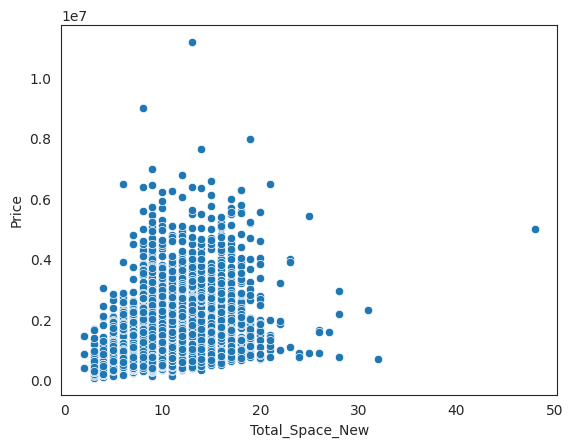

In [ ]:
sns.scatterplot(data=data,x='Total_Space_New',y='Price')


In [ ]:
# missing value treatment for landsize
data.groupby(['Regionname','Type'])[['Landsize']].median()

Landsize
Regionname                 Type          
Eastern Metropolitan       h      693.500
                           t      236.000
                           u      208.000
Eastern Victoria           h      840.000
                           u      230.000
Northern Metropolitan      h      482.000
                           t      145.000
                           u       50.000
Northern Victoria          h      737.500
                           u      315.000
South-Eastern Metropolitan h      632.000
                           t      248.000
                           u      210.000
Southern Metropolitan      h      593.000
                           t      267.000
                           u       50.000
Western Metropolitan       h      537.000
                           t      200.000
                           u       80.000
Western Victoria           h      603.000

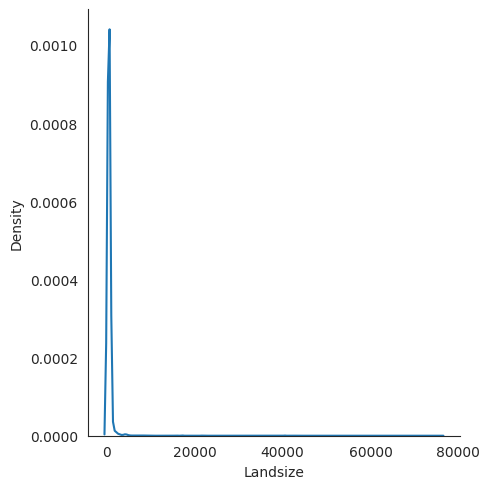

In [ ]:
sns.displot(data=data,x='Landsize',kind='kde')

In [ ]:
data['Landsize'] = data['Landsize'].fillna(value=data.groupby(['Regionname','Type'])['Landsize'].transform('median'))

In [ ]:
pd.DataFrame(
    {'Count':data.isnull().sum()[data.isnull().sum()>0],
              "Percentage" : (data.isnull().sum()[data.isnull().sum()>0]/data.shape[0])*100
     })

,Count,Percentage
BuildingArea,16573,61.150
YearBuilt,15117,55.778
Distance_bins,58,0.214
AgeOfProp,15117,55.778


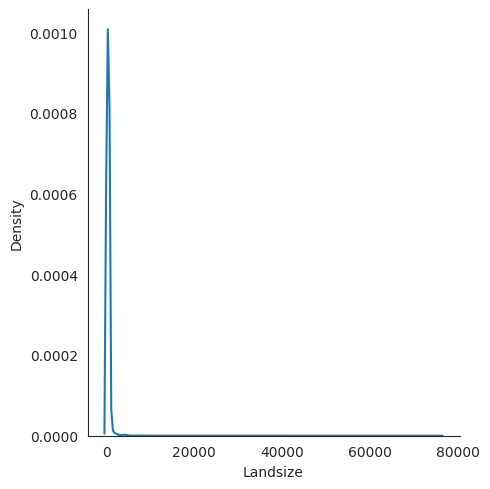

In [ ]:
sns.displot(data=data,x='Landsize',kind='kde')

In [ ]:
# taking to remove 61% of the null value from the building area columns
new_data=data[data['BuildingArea'].notnull()]
new_data.head()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price,Distance_bins,AgeOfProp,Total_Space_New
0,Airport West,3,t,Nelson,2016-09-03,13.500,3042.000,3,2,1,303.000,225.000,2016.000,Western Metropolitan,3464,840000,NearBy,0.000,9
1,Albert Park,2,h,hockingstuart,2016-09-03,3.300,3206.000,2,1,0,120.000,82.000,1900.000,Southern Metropolitan,3280,1275000,NearBy,116.000,5
3,Alphington,4,h,Brace,2016-09-03,6.400,3078.000,3,2,4,853.000,263.000,1930.000,Northern Metropolitan,2211,2000000,NearBy,86.000,13
5,Altona,3,h,Greg,2016-09-03,13.800,3018.000,3,2,1,352.000,242.000,2015.000,Western Metropolitan,5301,520000,NearBy,1.000,9
6,Altona North,5,h,FN,2016-09-03,11.100,3025.000,5,3,6,592.000,251.000,1965.000,Western Metropolitan,5132,1085000,NearBy,51.000,19


In [ ]:
new_data.shape

(10529, 19)

In [ ]:
# dropping columns building area , yearbuilt and ageofprop
data=data.drop(['BuildingArea','YearBuilt','AgeOfProp'],axis=1)

In [ ]:
data.to_csv('/content/drive/MyDrive/Edgeverve datasets/Melburne_Housing_NoMissing_Data.csv',index=False)

In [ ]:
path='/content/drive/MyDrive/Edgeverve datasets/Melburne_Housing_NoMissing_Data.csv'
df = pd.read_csv(path)
df.head()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,Regionname,Propertycount,Price,Distance_bins,Total_Space_New
0,Airport West,3,t,Nelson,2016-09-03,13.500,3042.000,3,2,1,303.000,Western Metropolitan,3464,840000,NearBy,9
1,Albert Park,2,h,hockingstuart,2016-09-03,3.300,3206.000,2,1,0,120.000,Southern Metropolitan,3280,1275000,NearBy,5
2,Albert Park,2,h,Thomson,2016-09-03,3.300,3206.000,2,1,0,159.000,Southern Metropolitan,3280,1455000,NearBy,5
3,Alphington,4,h,Brace,2016-09-03,6.400,3078.000,3,2,4,853.000,Northern Metropolitan,2211,2000000,NearBy,13
4,Alphington,3,h,Jellis,2016-09-03,6.400,3078.000,3,2,2,208.000,Northern Metropolitan,2211,1110000,NearBy,10


In [ ]:
df.isna().sum()

,0
Suburb,0
Rooms,0
Type,0
SellerG,0
Date,0
Distance,0
Postcode,0
Bedroom,0
Bathroom,0
Car,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27102 entries, 0 to 27101
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Suburb           27102 non-null  object 
 1   Rooms            27102 non-null  int64  
 2   Type             27102 non-null  object 
 3   SellerG          27102 non-null  object 
 4   Date             27102 non-null  object 
 5   Distance         27102 non-null  float64
 6   Postcode         27102 non-null  float64
 7   Bedroom          27102 non-null  int64  
 8   Bathroom         27102 non-null  int64  
 9   Car              27102 non-null  int64  
 10  Landsize         27102 non-null  float64
 11  Regionname       27102 non-null  object 
 12  Propertycount    27102 non-null  int64  
 13  Price            27102 non-null  int64  
 14  Distance_bins    27044 non-null  object 
 15  Total_Space_New  27102 non-null  int64  
dtypes: float64(3), int64(7), object(6)
memory usage: 3.3+ MB


#### Outlier handling

In [ ]:
# selecting all numeric columns
numeric_columns=df.select_dtypes(include=['number']).columns
len(numeric_columns)

10

#### visualize the outliers present in dataset

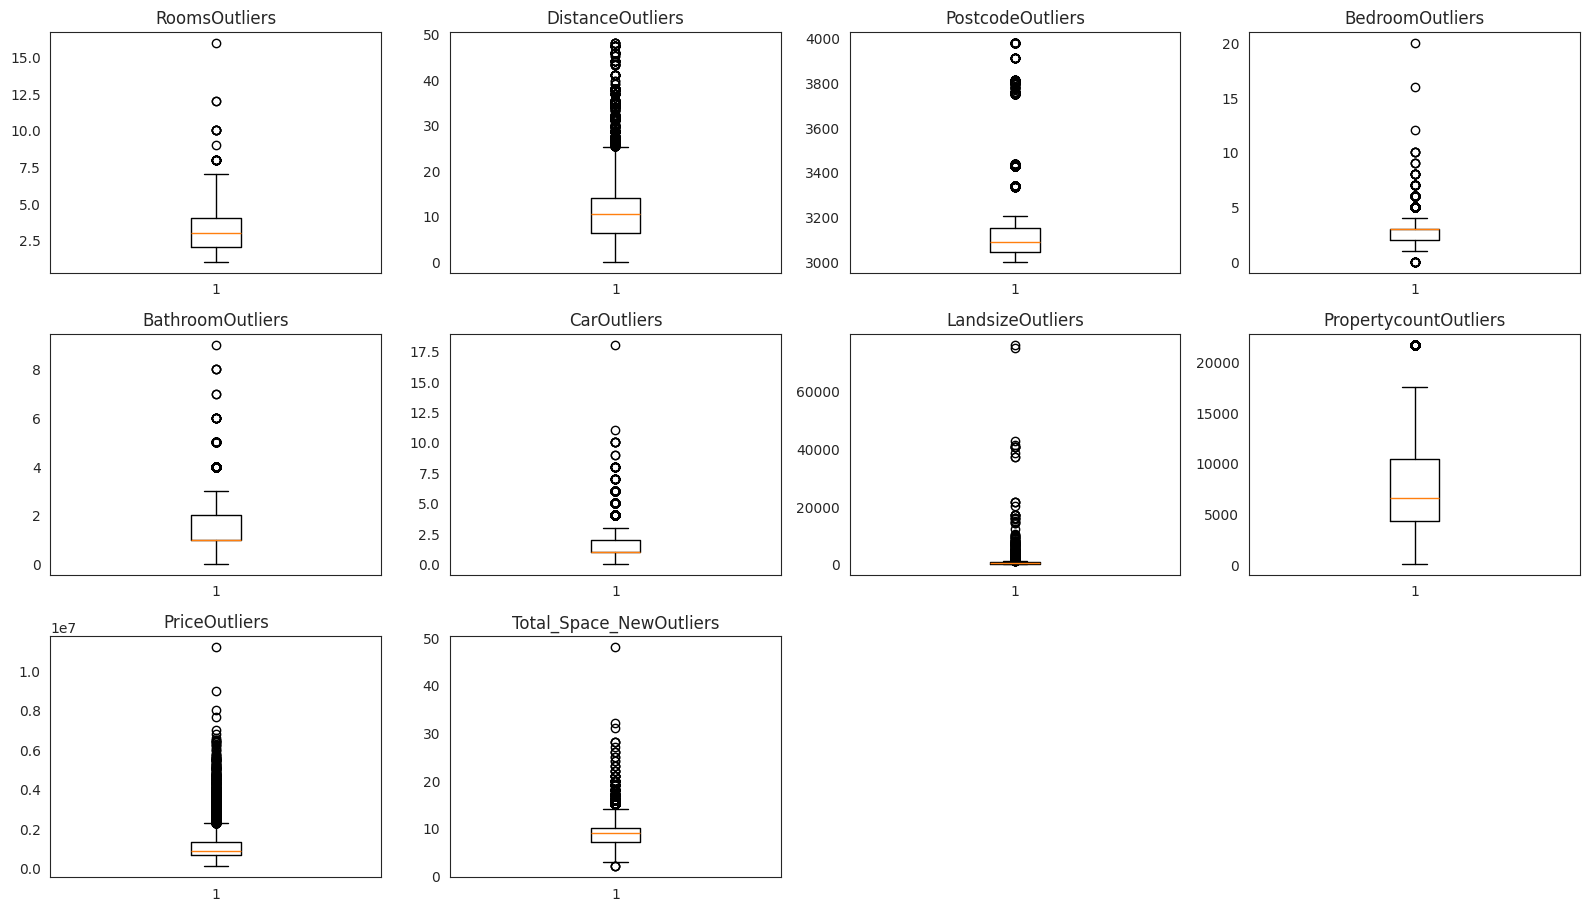

In [ ]:
plt.figure(figsize=(16,12))
for index,var in enumerate(numeric_columns):
  plt.subplot(4,4,index+1)
  plt.boxplot(df[var])
  plt.tight_layout()
  plt.title(var+"Outliers")

plt.show()

#### Find the percentage of outliers in each column using IQR

In [ ]:
Q1=df[numeric_columns].quantile(0.25)  # finding 25th percentile
Q3=df[numeric_columns].quantile(0.75)

# iqr
IQR=Q3-Q1
# lower bound
lower_whisker = Q1 - 1.5*IQR
#UPPER BOUND
upper_shisker= Q3 + 1.5*IQR

In [ ]:
IQR

,0
Rooms,2.000
Distance,7.600
Postcode,107.000
Bedroom,1.000
Bathroom,1.000
Car,1.000
Landsize,439.000
Propertycount,6118.000
Price,665000.000
Total_Space_New,3.000


In [ ]:
lower_whisker

,0
Rooms,-1.000
Distance,-5.000
Postcode,2885.500
Bedroom,0.500
Bathroom,-0.500
Car,-0.500
Landsize,-469.500
Propertycount,-4883.000
Price,-362500.000
Total_Space_New,2.500


In [ ]:
upper_shisker

,0
Rooms,7.000
Distance,25.400
Postcode,3313.500
Bedroom,4.500
Bathroom,3.500
Car,3.500
Landsize,1286.500
Propertycount,19589.000
Price,2297500.000
Total_Space_New,14.500


In [ ]:
# percentage
((df[numeric_columns]< lower_whisker) | (df[numeric_columns] > upper_shisker)).sum()/df.shape[0]*100

,0
Rooms,0.085
Distance,4.343
Postcode,2.911
Bedroom,4.195
Bathroom,0.871
Car,4.306
Landsize,1.742
Propertycount,2.671
Price,4.660
Total_Space_New,3.498


#### creating a function to floor and cap/clip outliers in a column

In [ ]:
def treat_outliers(df,col):
  Q1=df[col].quantile(0.25)  # finding 25th percentile
  Q3=df[col].quantile(0.75)

  # iqr
  IQR=Q3-Q1
  # lower bound
  lower_whisker = Q1 - 1.5*IQR
  #UPPER BOUND
  upper_whisker= Q3 + 1.5*IQR
  # all the values smaller than lower whisker will assigned the value of lower whisker
  # all the values larger than upper whisker will assigned the value of upper whisker
  # assignment will be done by this np.clip()
  df[col]=np.clip(df[col],lower_whisker,upper_whisker)
  return df


#### Treating Room outliers

<Axes: xlabel='Rooms'>

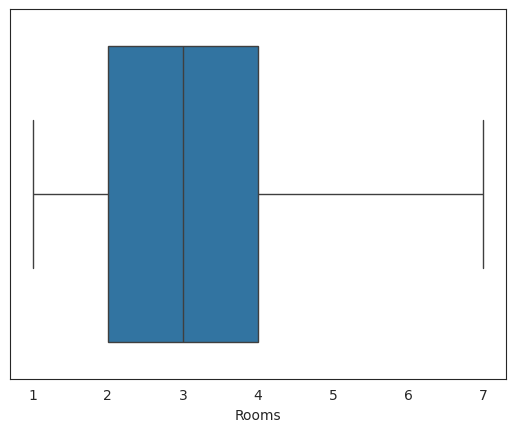

In [ ]:
data = treat_outliers(df,'Rooms')
sns.boxplot(data=data,x='Rooms')

#### Treating outlier for Bedroom , Car ,Bathroom , Landsize

In [ ]:
data = treat_outliers(df,'Bedroom')
data = treat_outliers(df,'Car')
data = treat_outliers(df,'Bathroom')
data = treat_outliers(df,'Landsize')

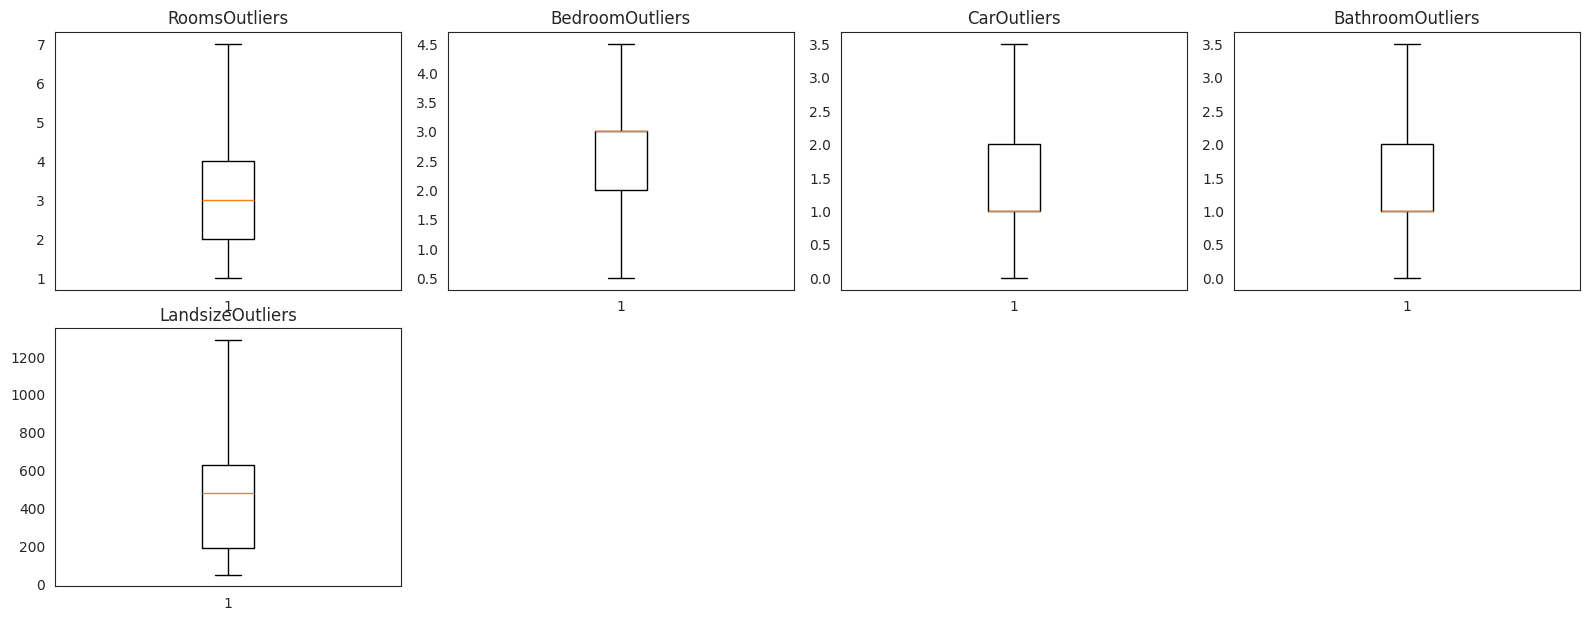

In [ ]:
n_columns=["Rooms","Bedroom","Car","Bathroom","Landsize"]
plt.figure(figsize=(16,12))
for index,var in enumerate(n_columns):
  plt.subplot(4,4,index+1)
  plt.boxplot(df[var])
  plt.tight_layout()
  plt.title(var+"Outliers")

- all the outliers have been treated for rooms,bedrooms,bathrooms, car and landsize

- we observe that data type of bedroom,bathroom and car has changed to float which we should change to integer type

- we can also see that distribution of landsize column doesnt look heavily right skewed

#### Changing data type of bedroom, bathroom and car to int

In [ ]:
df['Bedroom']= df['Bedroom'].astype(int)
df['Bathroom']= df['Bathroom'].astype(int)
df['Car']= df['Car'].astype(int)


In [ ]:
df.to_csv("/content/drive/MyDrive/Edgeverve datasets/Melbourne_Housing_Nooutliers.csv",index=False)